In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

# Упражнение 1. Калибровка установки.

In [172]:
path = './data/'
path_to = 'кал_ибровка'

data = pd.read_csv(path + path_to, delimiter='\t')

data = data.drop([0, 9, 18])

angles = data['HWP_a2']
cc1 = data['Single Count 1']
cc2 = data['Single Count 2']

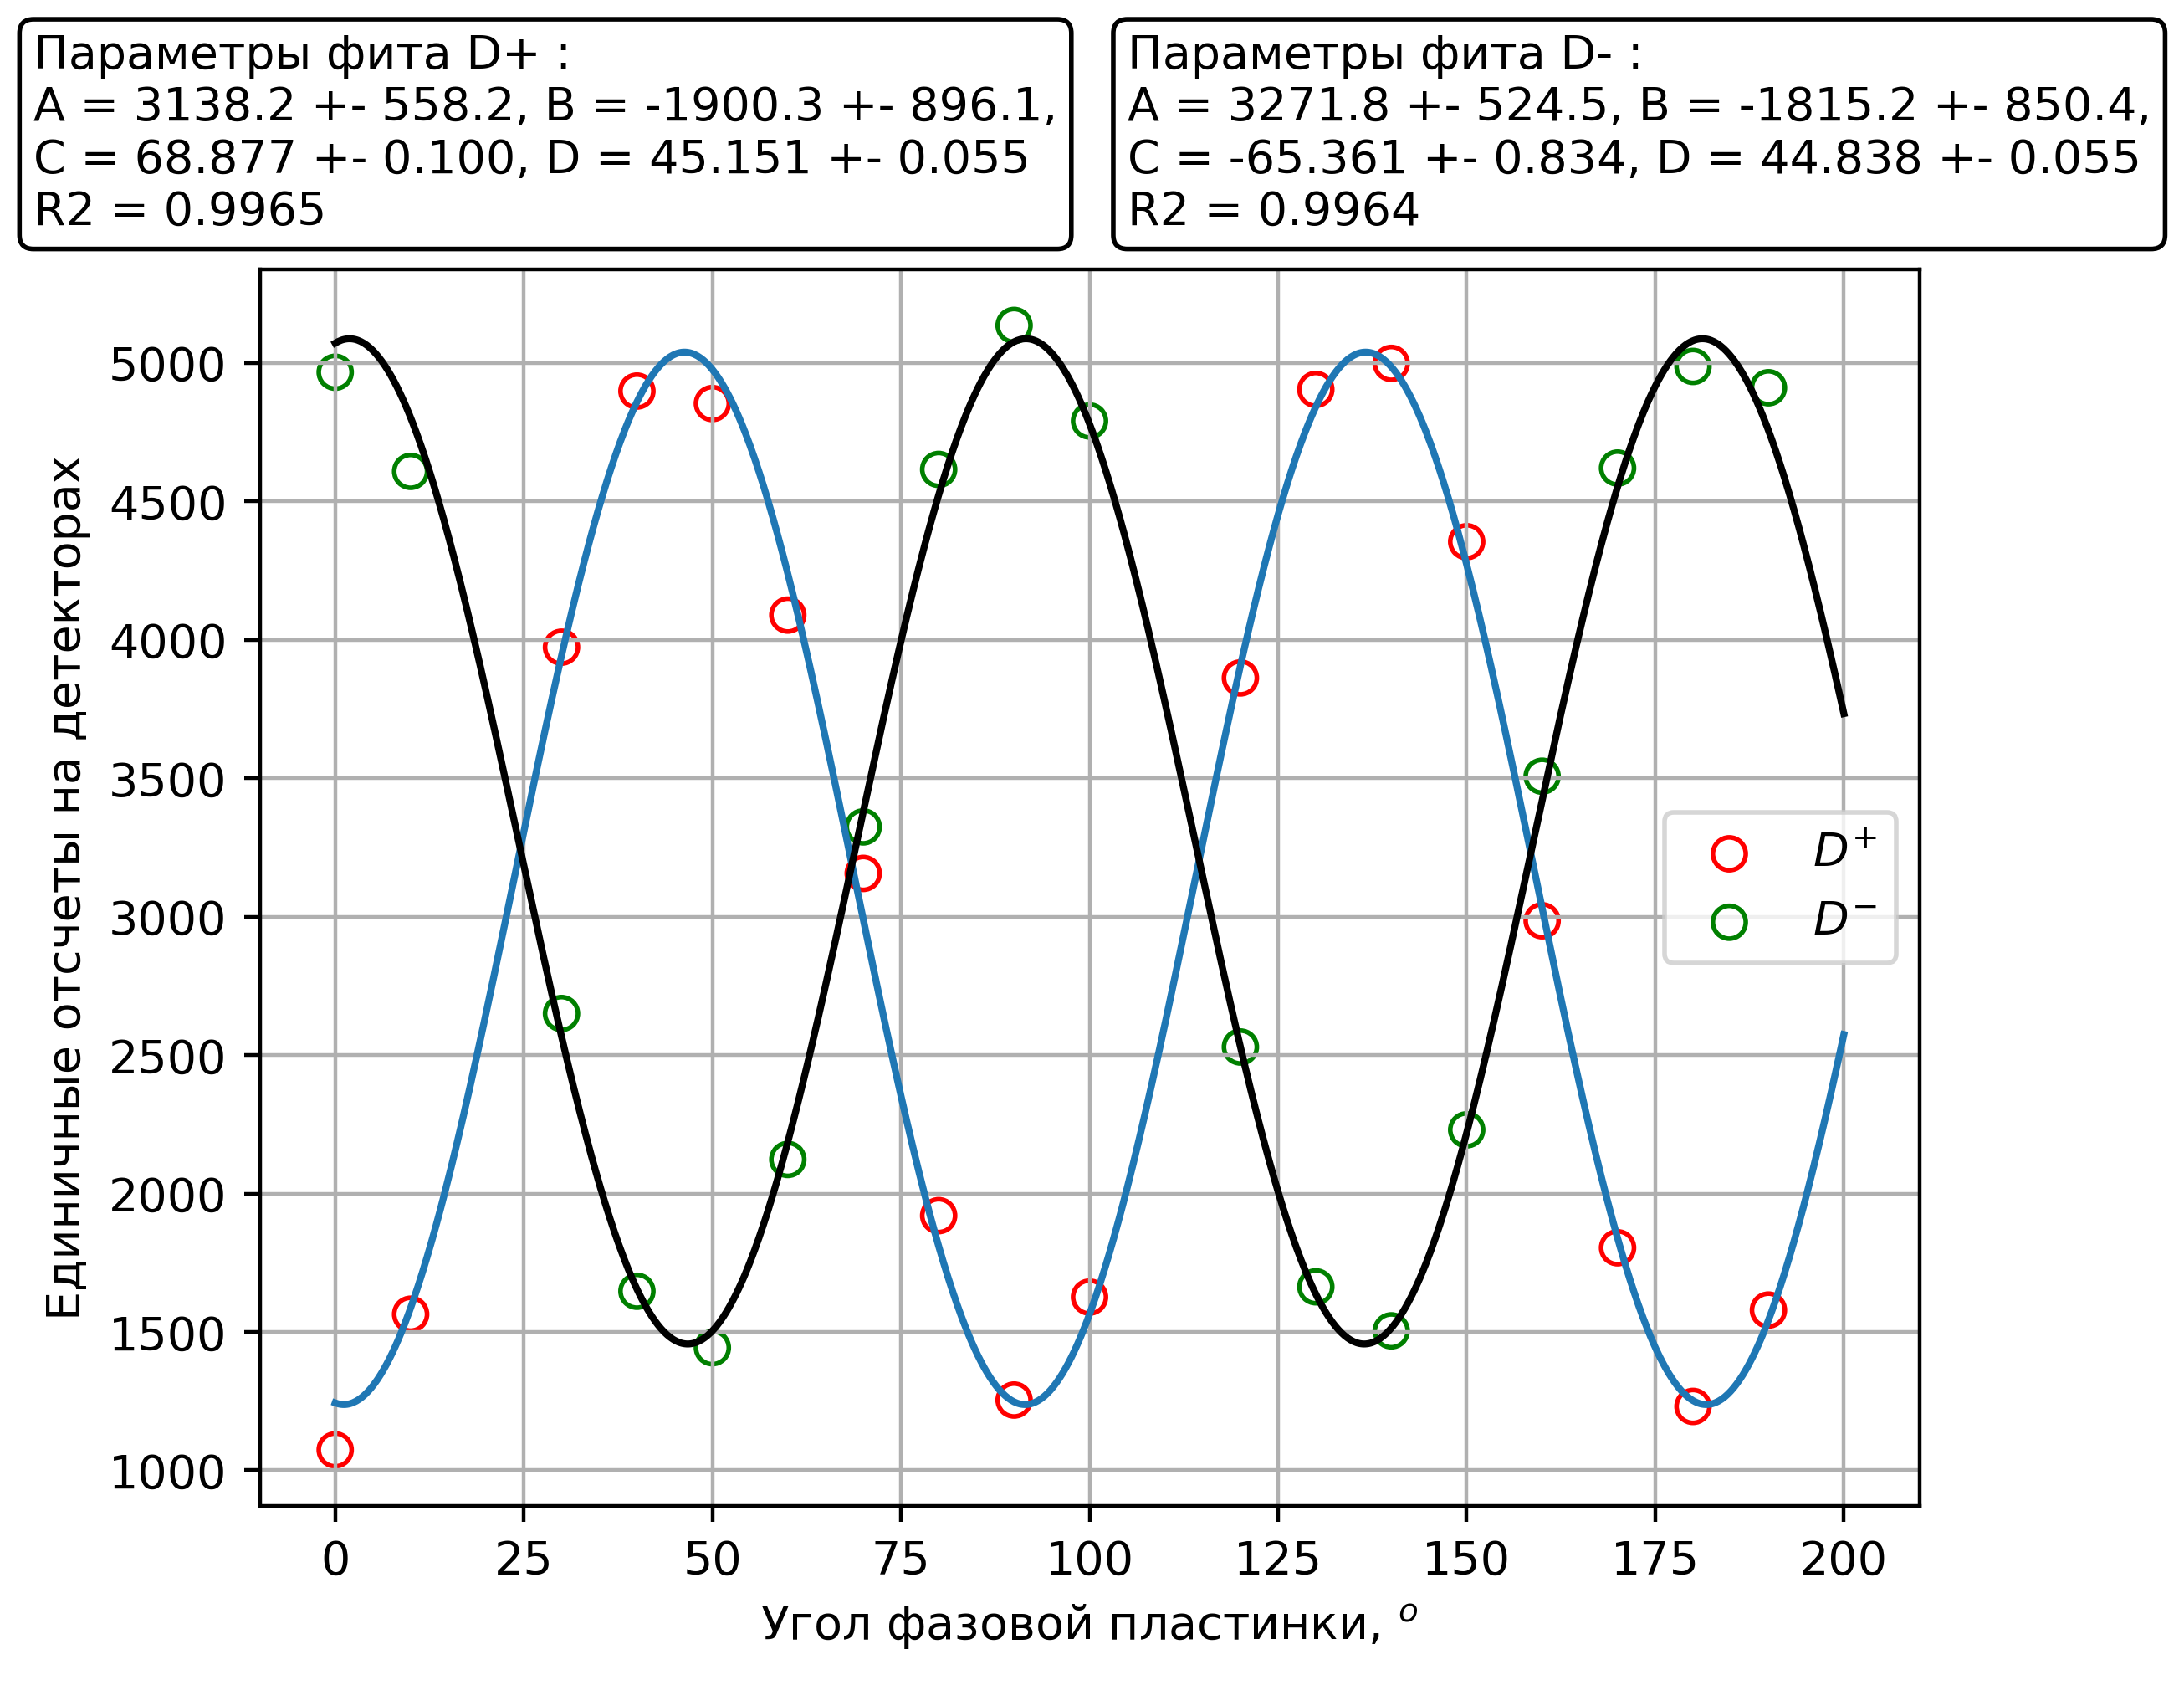

In [173]:
def func(x, A, B, C, D):
    return A + B*np.sin(np.pi*(x -C)/D)

def R2(y, anlge, popt):
    yhat = func(anlge, *popt)
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - (ss_res / ss_tot)

bbox_properties=dict(boxstyle='round, pad=0.3', fc='white', ls='-', lw=1)

angles_fit = np.linspace(0, 200, 1001)

# Фитим статистику на детекторе D+ 
popt_1, pcov_1 = curve_fit(func, angles, cc1, p0=[np.max(cc1)/2, (np.max(cc1) - np.min(cc1))/10, 0, 45])
A1, B1, C1, D1 = popt_1
sig_A1, sig_B1, sig_C1, sig_D1 = np.diag(pcov_1)

# Фитим статистику на детекторе D- 
popt_2, pcov_2 = curve_fit(func, angles, cc2, p0=[np.max(cc1)/2, (np.max(cc1) - np.min(cc1))/10, 0, 45])
A2, B2, C2, D2 = popt_2
sig_A2, sig_B2, sig_C2, sig_D2 = np.diag(pcov_2)

plt.figure(dpi = 400)
plt.scatter(angles, cc1, facecolor='none', edgecolors='red', marker='o', s=50, label=r'$D^{+}$')
plt.scatter(angles, cc2, facecolor='none', edgecolors='green', marker='o', s=50, label=r'$D^{-}$')

plt.plot(angles_fit, func(angles_fit, *popt_1))
plt.plot(angles_fit, func(angles_fit, *popt_2), color='black')
plt.grid()
plt.legend()
plt.xlabel(r'Угол фазовой пластинки, $^{o}$')
plt.ylabel('Единичные отсчеты на детекторах')

plt.text(-40,np.max(cc1)*1.1, f'Параметры фита D+ :\nA = {A1:.1f} +- {sig_A1:.1f}, B = {B1:.1f} +- {sig_B1:.1f},\nC = {C1:.3f} +- {sig_C1:.3f}, D = {D1:.3f} +- {sig_D1:.3f}\nR2 = {R2(cc1, angles, popt_1):.4f}',c = 'black', bbox = bbox_properties)
plt.text(105,np.max(cc1)*1.1, f'Параметры фита D- :\nA = {A2:.1f} +- {sig_A2:.1f}, B = {B2:.1f} +- {sig_B2:.1f},\nC = {C2:.3f} +- {sig_C2:.3f}, D = {D2:.3f} +- {sig_D2:.3f}\nR2 = {R2(cc2, angles, popt_2):.4f}',c = 'black', bbox = bbox_properties)
plt.show()

In [72]:
omega_1 = np.pi/D1
omega_2 = np.pi/D2

sig_om_1 = np.pi/D1**2 * sig_D1
sig_om_2 = np.pi/D2**2 * sig_D2

print(f'Частота D+: {omega_1:.4f} +- {sig_om_1:.4f}')
print(f'Частота D-: {omega_2:.4f} +- {sig_om_2:.4f}')

Частота D+: 0.0696 +- 0.0001
Частота D-: 0.0701 +- 0.0001


# Упражнение 2. Статистика фотоотчетов.

Расчет для темновых фотонов

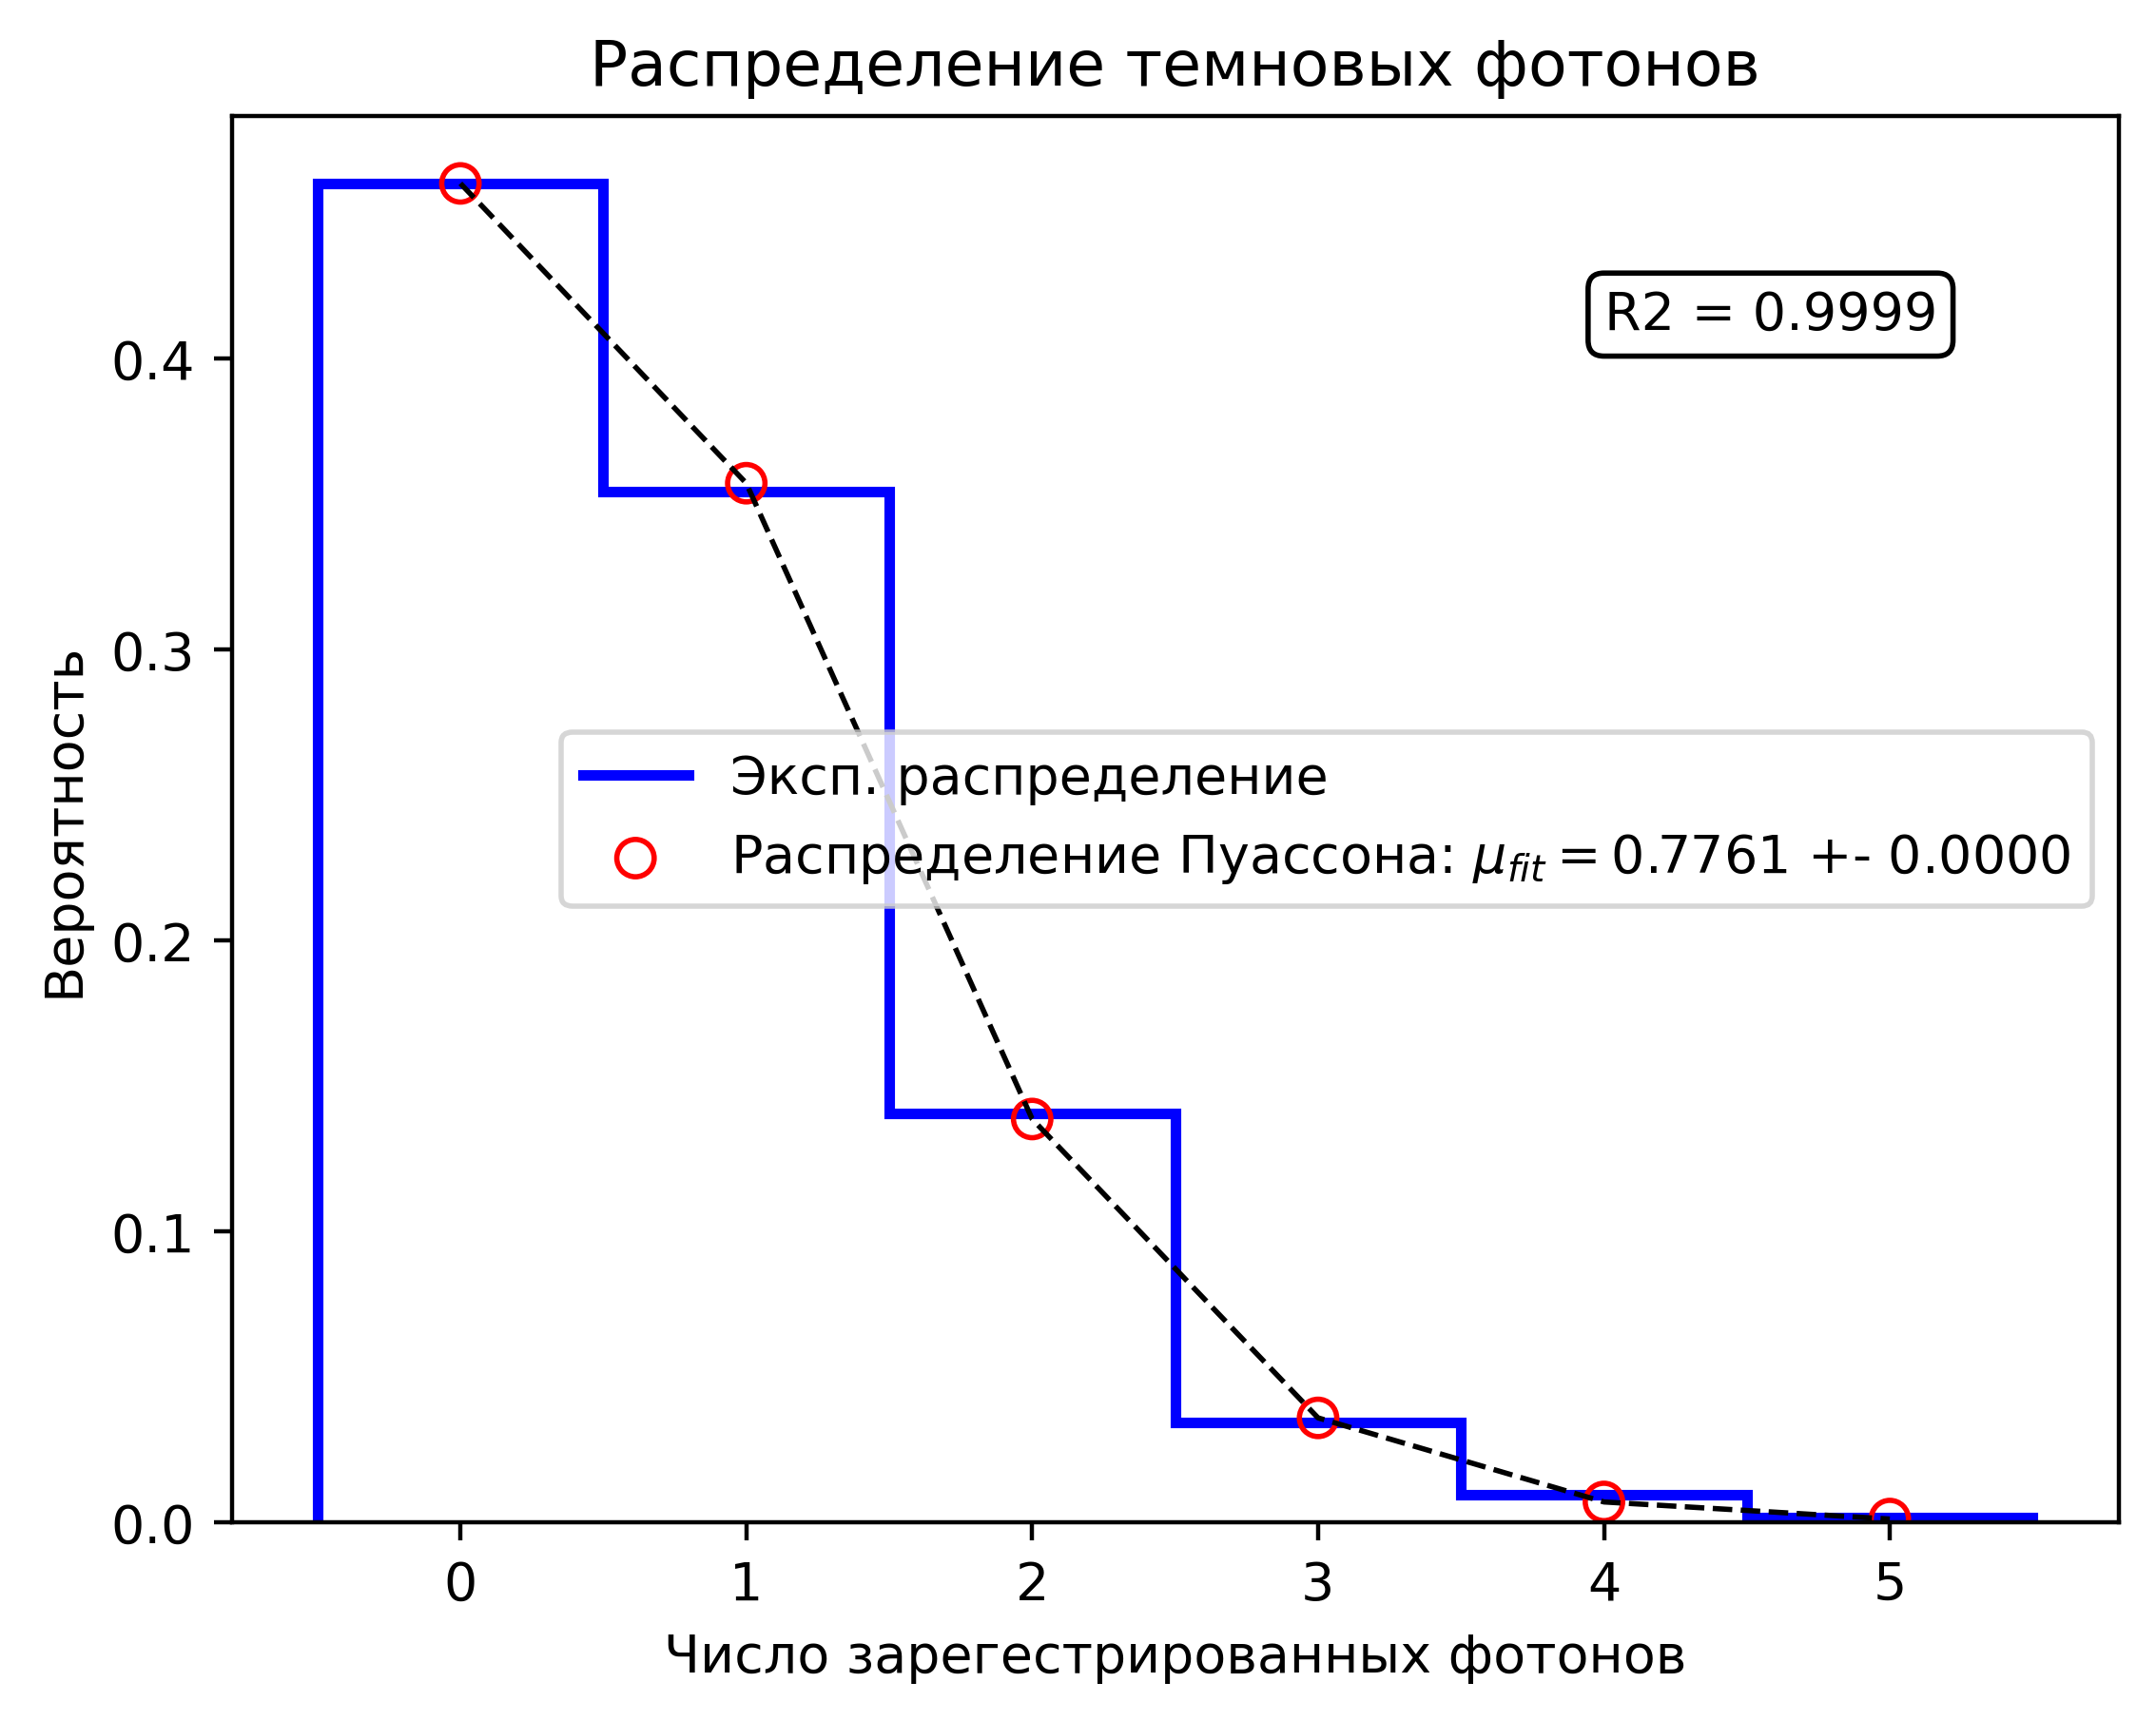

Экспериментальные значения:  <mu> = 0.7832, disp(mu) = 0.8001


In [176]:
from math import factorial

path_to = 'schet'

def func(x, mu):
    probs = np.array([])
    for i in x:
        i = int(i)
        probs = np.append(probs, [(mu**(i)/factorial(i)) * np.exp(-mu)])
    return probs

data = pd.read_csv(path + path_to, delimiter='\t')

shadow = data['Single Count 2']

# Что намерили
vals, bins = np.histogram(shadow, bins = [0, 1, 2, 3, 4, 5, 6])

# Что нафитили
x = np.array([0, 1, 2, 3, 4, 5], dtype=int)
mu, sig_mu = curve_fit(func, x, vals/sum(vals), p0=[0.73])

mu_l = mu[0]
sig_mu_l = sig_mu[0][0]

plt.figure(dpi=400)
plt.stairs(vals/np.sum(vals), bins-0.5, color='blue', linewidth = 2, label='Эксп. распределение')
plt.plot(x, func(x, mu_l), color='black', linewidth=1, linestyle='--')
plt.scatter(x, func(x, mu_l), s=50, facecolor='none', edgecolors='red', marker='o', label=r'Распределение Пуассона: $\mu_{fit} = $' + f'{mu_l:.4f} +- {sig_mu_l:.4f}')
plt.legend()
plt.xlabel('Число зарегестрированных фотонов')
plt.ylabel('Вероятность')
plt.text(4,np.max(vals/sum(vals))-0.05, f'R2 = {R2(vals/np.sum(vals), x, mu):.4f}', bbox = bbox_properties)
plt.title(r'Распределение темновых фотонов')
plt.show()

#Среднее число фотонов и дисперсия
mu_exp = np.dot(vals/sum(vals), x)
sig_mu_exp = np.dot(vals/sum(vals), x**2) - mu_exp**2
print(r'Экспериментальные значения:  ' + f'<mu> = {mu_exp:.4f}, disp(mu) = {sig_mu_exp:.4f}')

Расчет для сигнальных отсчетов

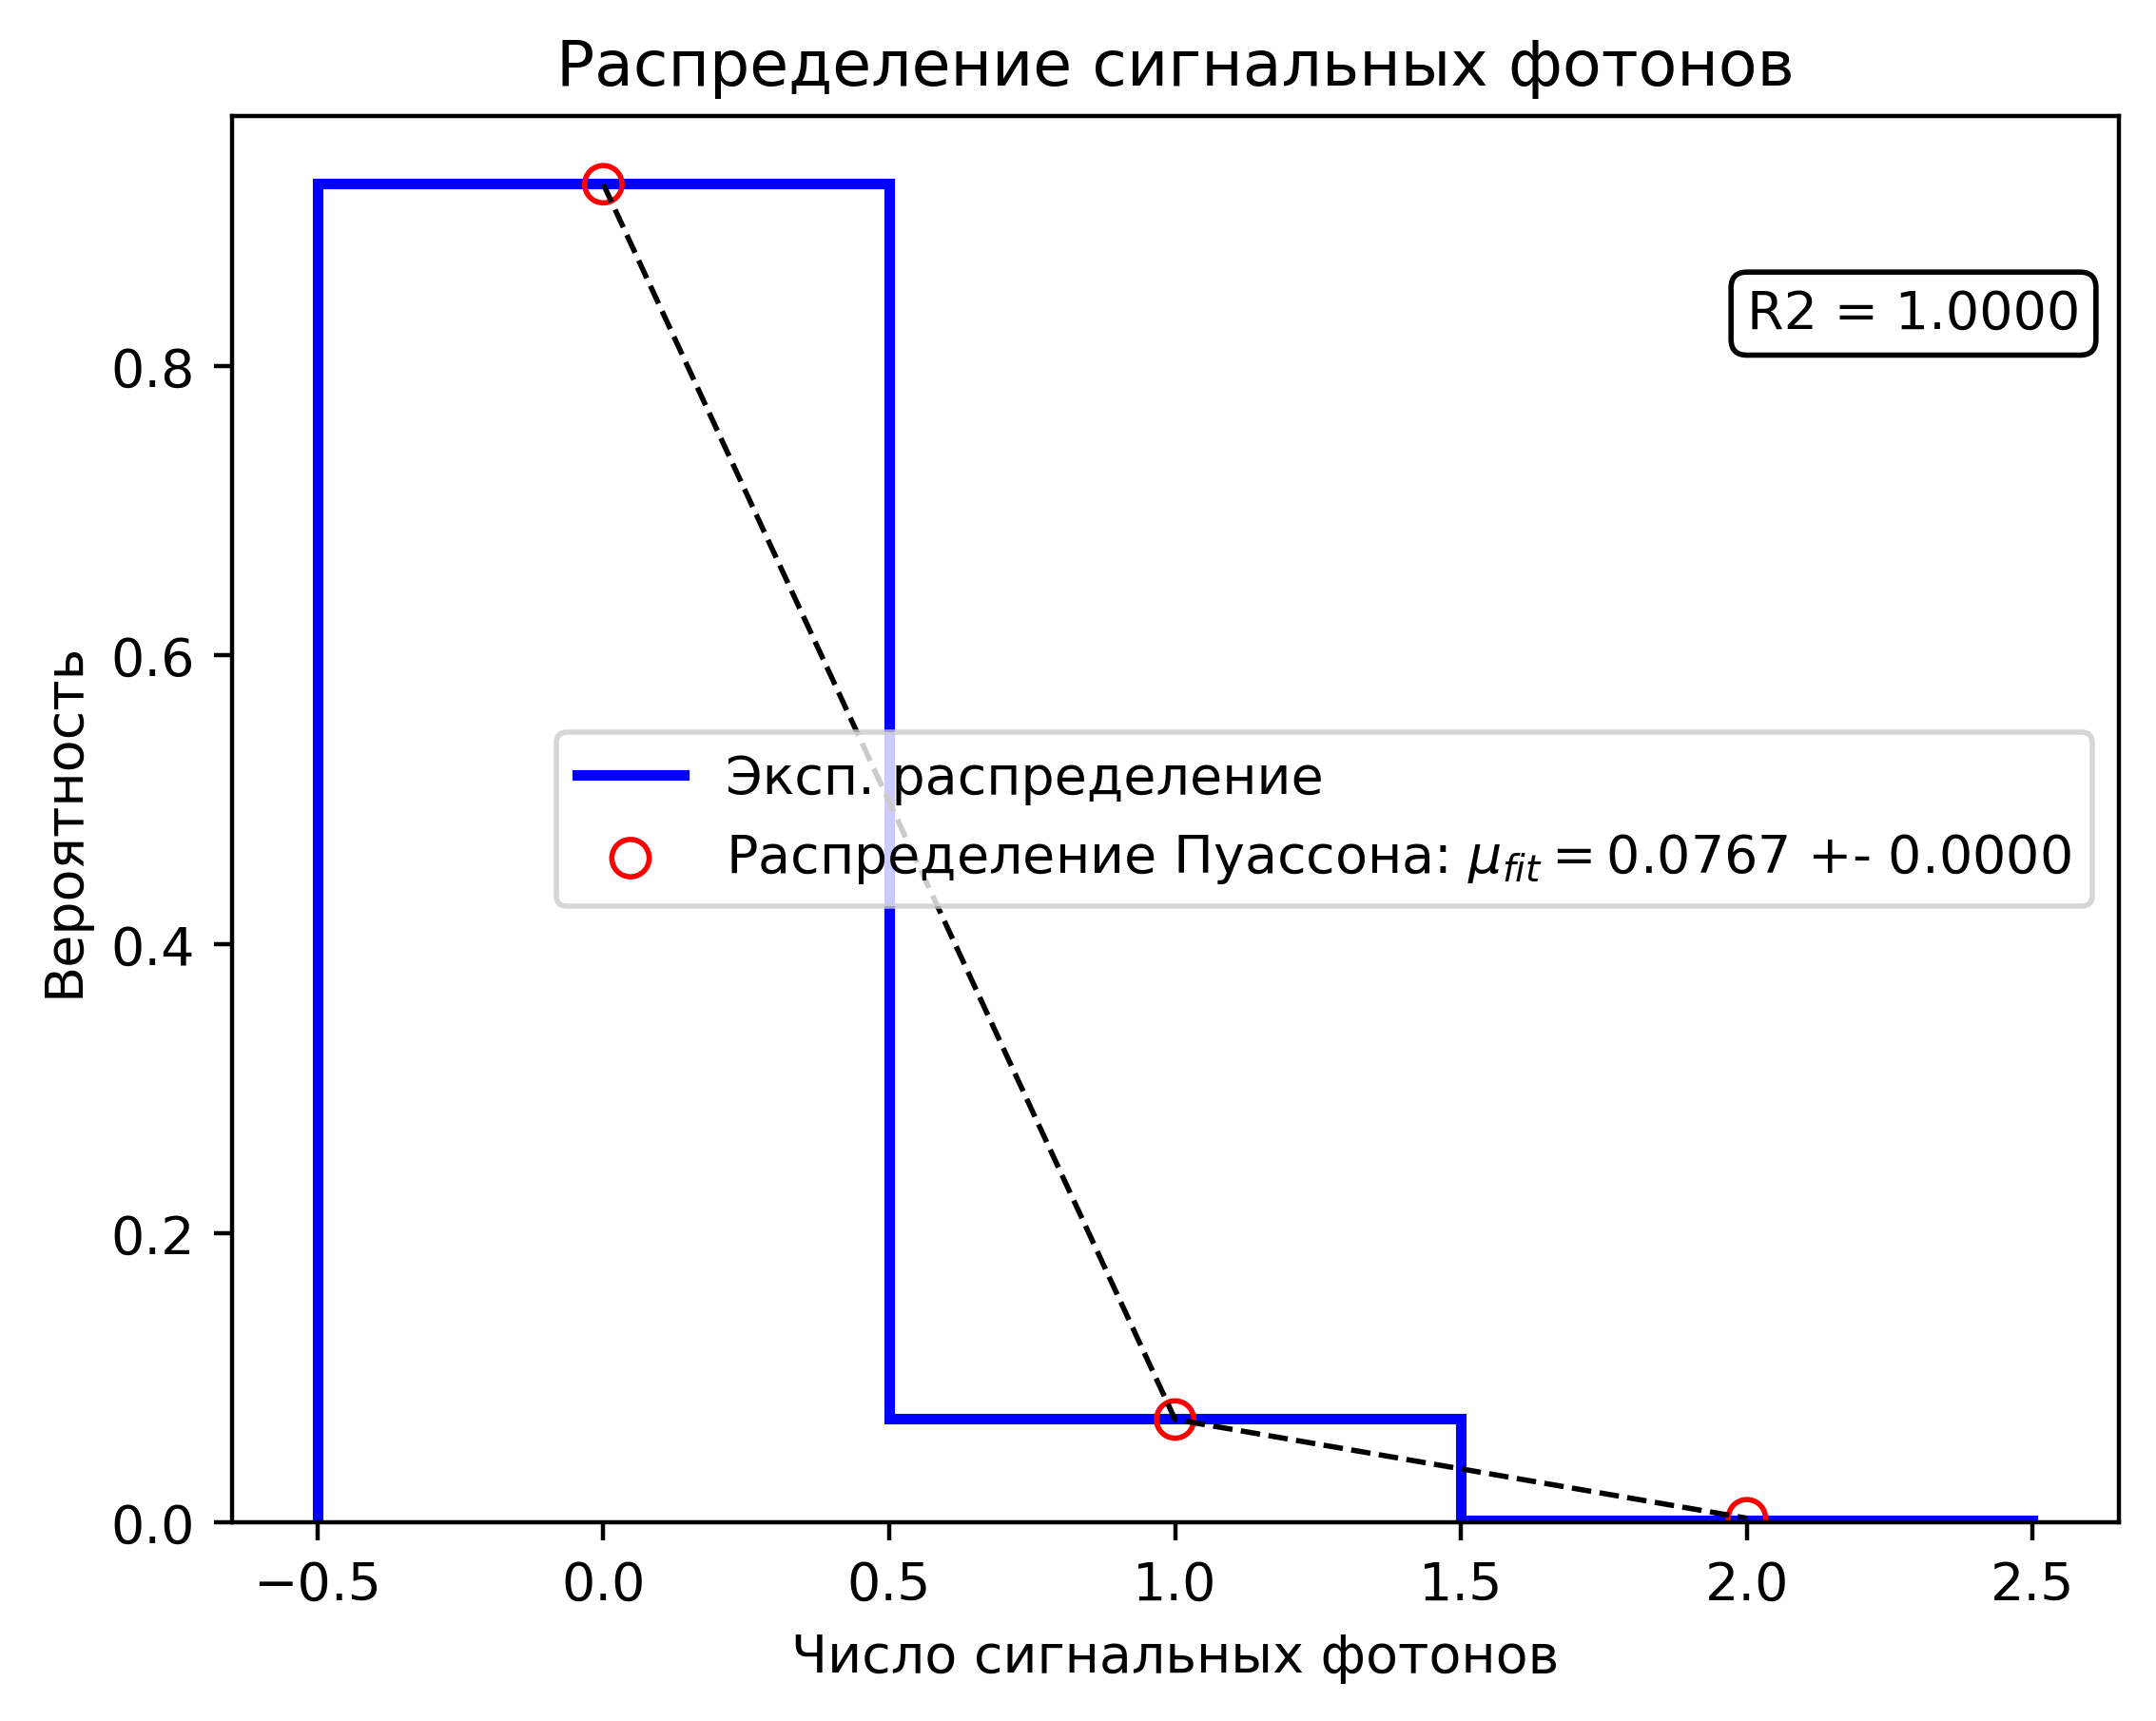

Экспериментальные значения:  <mu> = 0.0749, disp(mu) = 0.0724


In [177]:
real = data['Single Count 1']

# Что намерили
vals, bins = np.histogram(real, bins = [0, 1, 2, 3])

# Что нафитили
x = np.array([0, 1, 2], dtype=int)
mu, sig_mu = curve_fit(func, x, vals/sum(vals), p0=[0.73])

mu_l = mu[0]
sig_mu_l = sig_mu[0][0]

plt.figure(dpi=400)
plt.stairs(vals/np.sum(vals), bins-0.5, color='blue', linewidth = 2, label='Эксп. распределение')
plt.plot(x, func(x, mu_l), color='black', linewidth=1, linestyle='--')
plt.scatter(x, func(x, mu_l), s=50, facecolor='none', edgecolors='red', marker='o', label=r'Распределение Пуассона: $\mu_{fit} = $' + f'{mu_l:.4f} +- {sig_mu_l:.4f}')
plt.legend()
plt.xlabel('Число сигнальных фотонов')
plt.ylabel('Вероятность')
plt.text(2,np.max(vals/sum(vals))-0.1, f'R2 = {R2(vals/np.sum(vals), x, mu):.4f}', bbox = bbox_properties)
plt.title(r'Распределение сигнальных фотонов')
plt.show()

#Среднее число фотонов и дисперсия
mu_exp = np.dot(vals/sum(vals), x)
sig_mu_exp = np.dot(vals/sum(vals), x**2) - mu_exp**2
print(r'Экспериментальные значения:  ' + f'<mu> = {mu_exp:.4f}, disp(mu) = {sig_mu_exp:.4f}')

# Упражнени 3. Протокол КРК.

In [183]:
path_to = 'крк_new'

data = pd.read_csv(path + path_to, delimiter=",")
data

,Алиса,Боб,HWP_b1,Бит Алисы,HWP_b2,Бит Боба
0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,1.0,22.5,1.0
2,1.0,0.0,-22.5,1.0,22.5,0.0
3,1.0,1.0,22.5,1.0,22.5,1.0
4,0.0,0.0,45.0,1.0,22.5,1.0
5,0.0,0.0,45.0,0.0,0.0,0.0
6,1.0,1.0,22.5,0.0,0.0,1.0
7,1.0,0.0,-22.5,0.0,0.0,1.0
8,1.0,0.0,-22.5,1.0,22.5,0.0
9,0.0,1.0,0.0,0.0,0.0,1.0
